### Importing Libraries

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

### Loading the Dataset

In [101]:
df = pd.read_csv("employee_performance.csv")

### Analyzing the Dataset

In [102]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'MaritalStatus', 'EmpJobRole',
       'DistanceFromHomeKm', 'EmpEnvironmentSatisfaction', 'EmpHourlyRateEur',
       'EmpJobInvolvement', 'EmpJobSatisfaction', 'OverTimeHours',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceYears', 'EmpWorkLifeBalance',
       'YearsSinceLastPromotion', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [103]:
df.head()

,EmpNumber,Age,Gender,MaritalStatus,EmpJobRole,DistanceFromHomeKm,EmpEnvironmentSatisfaction,EmpHourlyRateEur,EmpJobInvolvement,EmpJobSatisfaction,OverTimeHours,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceYears,EmpWorkLifeBalance,YearsSinceLastPromotion,Attrition,PerformanceRating
0,E0000001,33,Male,Single,Train Conductor,10,4,33,3,4,No,12,4,11,2,0,No,3
1,E0000002,47,Male,Single,Train Conductor,14,4,32,3,1,No,12,4,21,3,1,No,3
2,E0000003,40,Male,Married,Train Conductor,5,4,38,4,4,Yes,21,3,21,3,1,No,4
3,E0000004,41,Male,Divorced,Logistics Coordinator,10,2,22,2,4,No,15,2,23,2,12,No,3
4,E0000005,60,Male,Single,Train Conductor,16,3,23,3,1,No,14,4,11,3,2,No,3


In [104]:
df.describe()

,Age,DistanceFromHomeKm,EmpEnvironmentSatisfaction,EmpHourlyRateEur,EmpJobInvolvement,EmpJobSatisfaction,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceYears,EmpWorkLifeBalance,YearsSinceLastPromotion,PerformanceRating
count,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000
mean,39.681962,10.375000,2.903481,26.931962,2.797468,2.837025,15.072785,2.655063,12.376582,2.764241,2.520570,2.882911
std,7.058177,7.905556,0.971147,5.459268,0.718861,1.071319,3.560358,1.092260,7.600398,0.711989,3.481837,0.553530
min,30.000000,2.000000,1.000000,20.000000,1.000000,1.000000,11.000000,1.000000,1.000000,1.000000,0.000000,2.000000
25%,34.000000,4.000000,2.000000,22.000000,2.000000,2.000000,12.000000,2.000000,7.000000,2.000000,0.000000,3.000000
50%,38.000000,8.000000,3.000000,23.000000,3.000000,3.000000,14.000000,3.000000,11.000000,3.000000,1.000000,3.000000
75%,44.000000,15.000000,4.000000,32.000000,3.000000,4.000000,17.000000,4.000000,15.000000,3.000000,4.000000,3.000000
max,60.000000,29.000000,4.000000,39.000000,4.000000,4.000000,25.000000,4.000000,38.000000,4.000000,15.000000,4.000000


In [105]:
df["PerformanceRating"].unique()

array([3, 4, 2])

###  Analyzing employees performance based on the Job Role

In [106]:
job_perf = df.groupby("EmpJobRole")["PerformanceRating"].mean().sort_values(ascending=False)
job_perf

EmpJobRole
Depot Driver                                3.000000
Maintenance Technician                      3.000000
Logistics Coordinator                       3.000000
City Bus Driver                             2.936170
Fleet Manager                               2.859375
Train Conductor                             2.855556
Operations manager                          2.848485
Environmental and Sustainability Manager    2.833333
Intercity Bus Driver                        2.775510
Name: PerformanceRating, dtype: float64

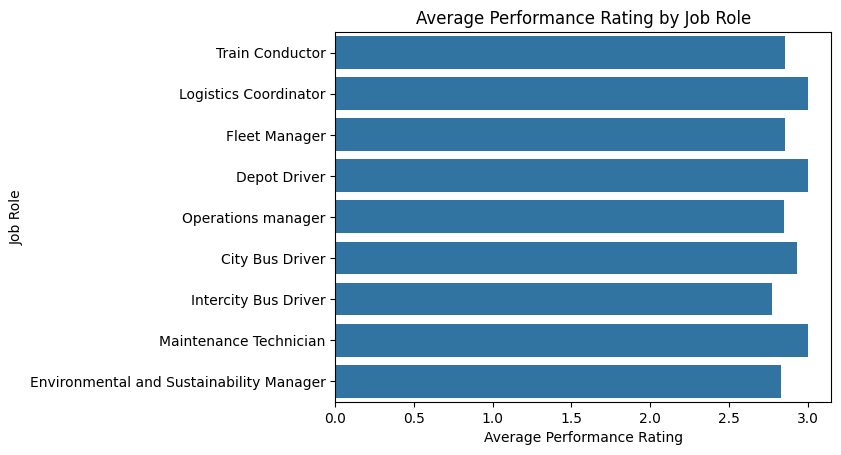

In [107]:
sns.barplot(x="PerformanceRating", y="EmpJobRole", data=df, errorbar=None, estimator="mean")
plt.title("Average Performance Rating by Job Role")
plt.xlabel("Average Performance Rating")
plt.ylabel("Job Role")
plt.show()

**Key Insights**


From the data, Depot Drivers, Maintenance Technicians, and Logistics Coordinators show the highest average performance rating (3.0), while Intercity Bus Drivers have the lowest (2.78). Most other roles cluster closely around the average, suggesting overall consistency with slight variation. This may reflect differences in job expectations, work environment, or support levels tied to each role.

### Checking for any Missing or Null values in the dateset

In [108]:
df.isnull().values.any()

np.False_

**Key Insights**

The dataset contains no missing values, so all records are complete and ready for analysis without needing data imputation or removal.

### Dropping Irrelevant Columns

In [109]:
df_relevant = df.drop(columns=['EmpNumber'])

**Key Insights**


In this dataset:

- **EmpNumber (Employee ID)** is a unique identifier and should be dropped because it doesn’t help the model learn patterns related to performance.

- All other columns contain relevant information about employee demographics, job, and work characteristics, so they should be kept.

Removing EmpNumber helps avoid overfitting since the model won’t learn patterns from unique IDs. Keeping other columns ensures the model has all relevant factors influencing performance.


### Feature engineering and transformation

**Label encoding binary variables**  
Binary categorical features like Gender, OverTimeHours, and Attrition were converted into numerical values (0 and 1). This preserves their binary nature without implying any order.

In [110]:
df_relevant['Gender'] = df_relevant['Gender'].map({'Male': 0, 'Female': 1})  
df_relevant['OverTimeHours'] = df_relevant['OverTimeHours'].map({'No': 0, 'Yes': 1})  
df_relevant['Attrition'] = df_relevant['Attrition'].map({'No': 0, 'Yes': 1})  

**One-hot encoding multiclass categorical variables**  
Features with multiple categories such as EmpJobRole and MaritalStatus were one-hot encoded, creating separate binary columns for each category to avoid any ordinal assumptions and allow the model to treat each category independently. The `drop_first=True` parameter prevents multicollinearity by dropping one dummy variable per set.

In [111]:
df_relevant = pd.get_dummies(df_relevant, columns=['EmpJobRole', 'MaritalStatus'], drop_first=True)

**Key Insights**


To prepare the dataset for machine learning modeling, all categorical variables were converted into numerical formats. This transformation is necessary because most machine learning algorithms require numerical input.

Binary categorical variables, such as Gender, OverTimeHours, and Attrition, were encoded using label encoding, where distinct categories are mapped to 0 and 1. This preserves the binary nature without implying any ordinal relationship.

For categorical variables with more than two classes, such as EmpJobRole and MaritalStatus, one-hot encoding was applied. This technique creates separate binary indicator variables for each category, preventing the introduction of any ordinal bias and allowing the model to interpret each category independently.

In [112]:
df_relevant

,Age,Gender,DistanceFromHomeKm,EmpEnvironmentSatisfaction,EmpHourlyRateEur,EmpJobInvolvement,EmpJobSatisfaction,OverTimeHours,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,...,EmpJobRole_Depot Driver,EmpJobRole_Environmental and Sustainability Manager,EmpJobRole_Fleet Manager,EmpJobRole_Intercity Bus Driver,EmpJobRole_Logistics Coordinator,EmpJobRole_Maintenance Technician,EmpJobRole_Operations manager,EmpJobRole_Train Conductor,MaritalStatus_Married,MaritalStatus_Single
0,33,0,10,4,33,3,4,0,12,4,...,False,False,False,False,False,False,False,True,False,True
1,47,0,14,4,32,3,1,0,12,4,...,False,False,False,False,False,False,False,True,False,True
2,40,0,5,4,38,4,4,1,21,3,...,False,False,False,False,False,False,False,True,True,False
3,41,0,10,2,22,2,4,0,15,2,...,False,False,False,False,True,False,False,False,False,False
4,60,0,16,3,23,3,1,0,14,4,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,48,0,2,2,33,4,2,0,12,4,...,False,False,False,False,False,False,False,True,True,False
628,37,1,3,4,22,4,4,1,20,2,...,False,False,False,False,False,False,False,True,False,False
629,37,0,10,4,20,4,4,0,17,1,...,False,True,False,False,False,False,False,False,False,True
630,50,0,28,4,23,4,3,1,11,3,...,False,True,False,False,False,False,False,False,True,False


### Analysis of Variables Correlated with Performance Rating

**Correlation matrix heatmap**

This heatmap shows how strongly variables are related to each other. Warm colors mean a positive link, cool colors mean a negative link. It helps quickly spot which factors affect employee performance the most.

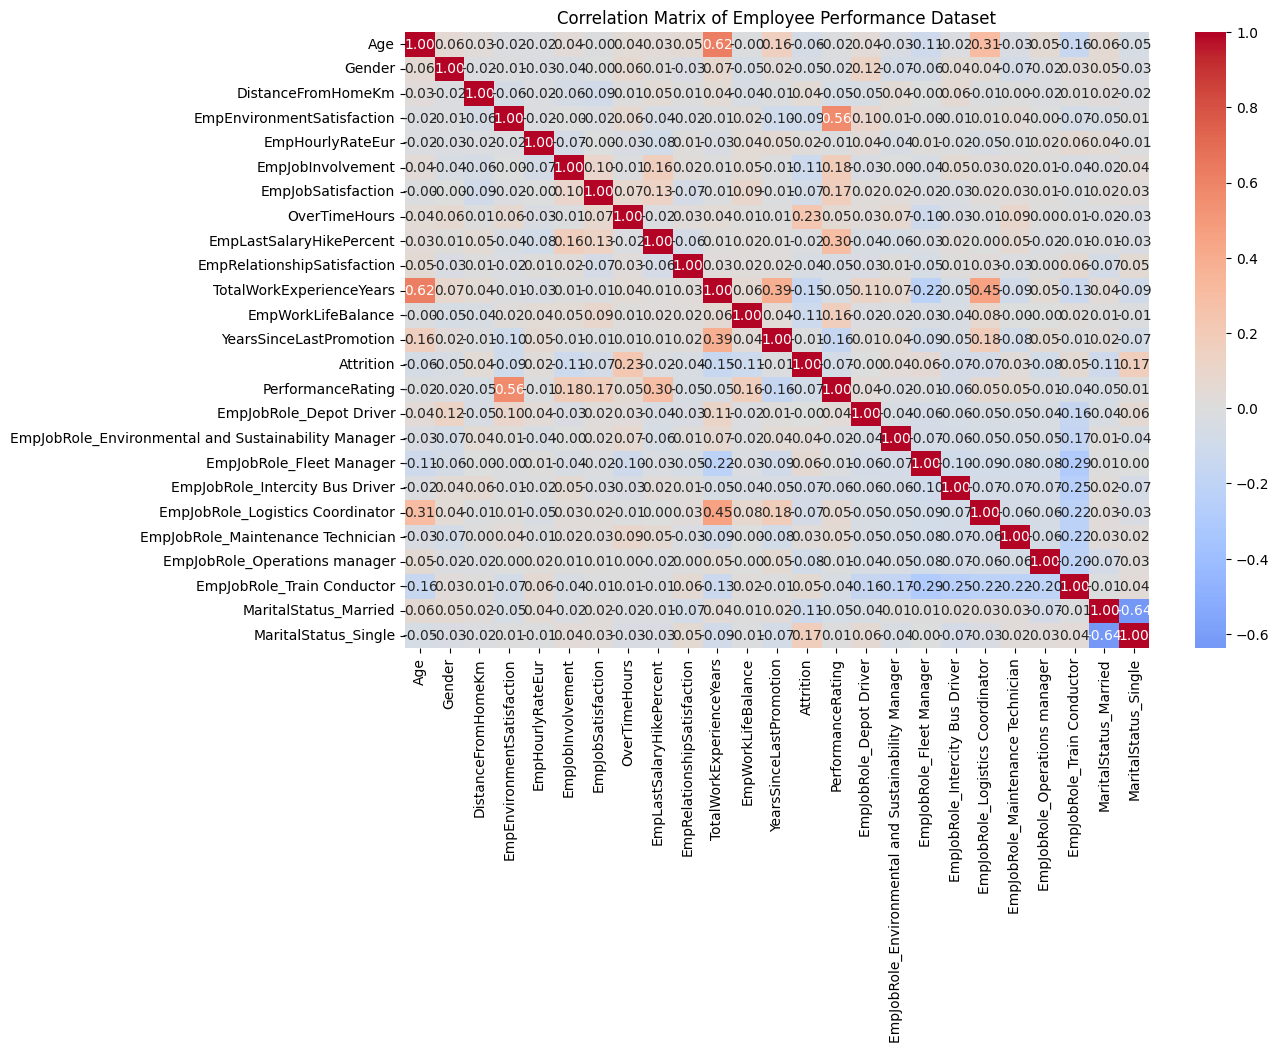

In [113]:
correlation_matrix  = df_relevant.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Matrix of Employee Performance Dataset")
plt.show()

In [114]:
# Get correlations with PerformanceRating excluding itself
corr_target = corr["PerformanceRating"].drop("PerformanceRating")

# Sort by actual correlation value descending (highest positive first)
sorted_corr = corr_target.sort_values(ascending=False)

print("\n");
print("| Variable                                             | Correlation with PerformanceRating |")
print("|------------------------------------------------------|------------------------------------|")
for var in sorted_corr.index:
    print(f"| {var:<52} | {corr_target[var]:>10.2f} |")



| Variable                                             | Correlation with PerformanceRating |
|------------------------------------------------------|------------------------------------|
| EmpEnvironmentSatisfaction                           |       0.56 |
| EmpLastSalaryHikePercent                             |       0.30 |
| EmpJobInvolvement                                    |       0.18 |
| EmpJobSatisfaction                                   |       0.17 |
| EmpWorkLifeBalance                                   |       0.16 |
| EmpJobRole_Logistics Coordinator                     |       0.05 |
| EmpJobRole_Maintenance Technician                    |       0.05 |
| OverTimeHours                                        |       0.05 |
| EmpJobRole_Depot Driver                              |       0.04 |
| MaritalStatus_Single                                 |       0.01 |
| EmpHourlyRateEur                                     |      -0.01 |
| EmpJobRole_Fleet Manager              

**Key Insights**


Employee Environment Satisfaction has the strongest positive correlation with performance, indicating that a better work environment greatly boosts employee output. Salary hikes, job involvement, job satisfaction, and work-life balance also show moderate positive links, suggesting these factors contribute to better performance.

On the other hand, Years Since Last Promotion and employee Attrition show negative correlations, meaning employees who have waited longer for promotion or those who leave tend to perform worse. Other factors like age, gender, and job role have minimal or no clear impact on performance in this dataset. Overall, focusing on improving workplace satisfaction and timely recognition could enhance performance.

### Defining the Problem Type

There are two main types of supervised learning problems: **regression** and **classification**. In regression, the goal is to predict a **continuous numeric value**, such as salary or temperature. In contrast, classification focuses on predicting **discrete class labels**, like "low", "medium", or "high" performance.

In our case, although `PerformanceRating` is represented numerically (1 to 4), these values are **ordinal categories**, not continuous numbers. Predicting a rating of, say, 2.98 doesn't hold practical meaning, since employee performance is assessed in whole-number categories.

**Therefore, it makes more sense to treat this as a classification problem**. This allows us to use powerful classification algorithms and evaluate the model using appropriate metrics like **accuracy, precision, recall, and F1-score**, which align with our real-world objective of categorizing employee performance.

| Aspect               | Regression                               | Classification                           |
|----------------------|------------------------------------------|-------------------------------------------|
| Output Type          | Continuous numeric values                | Discrete class labels                     |
| Example Prediction   | Predicting salary: €55,430               | Predicting category: "High Performer"     |
| Target Variable Type | Real numbers (e.g., float, int)          | Categorical or ordinal (e.g., 1, 2, 3, 4) |
| Evaluation Metrics   | MSE, RMSE, MAE, R²                        | Accuracy, Precision, Recall, F1-score     |
| Suitable For         | Trend estimation, forecasting            | Classification tasks, categorization      |



### Selecting Suitable Models

There are several supervised classification models suitable for predicting employee performance based on the given dataset. Each model has its own strengths and weaknesses:

- **Random Forest:** A robust ensemble method that handles non-linearity well and performs effectively on tabular data. It is less prone to overfitting and can manage feature importance inherently.
- **Support Vector Machine (SVM):** Effective for small to medium datasets with clear margins between classes. However, it can be slower on larger datasets and usually requires feature scaling.
- **Logistic Regression:** A simple and interpretable model best suited for problems with linear decision boundaries. It might not capture complex patterns in data.
- **XGBoost:** A powerful gradient boosting algorithm that handles missing data and often provides state-of-the-art results. It can be more complex and computationally intensive.
- **K-Nearest Neighbors (KNN):** Easy to implement but can be slow with large datasets and sensitive to irrelevant features and noise.
- **Neural Network (MLPClassifier):** Capable of modeling complex patterns but requires careful tuning and might be overkill for smaller datasets.

Given the dataset size of 632 rows and the need for a balance between performance and interpretability, **Random Forest** is chosen. It provides strong predictive performance, handles different types of data well, and is less sensitive to hyperparameter tuning compared to other models. This makes it suitable for initial modeling and provides meaningful insights into feature importance.


### Training a Random Forest Classifier to Predict Employee Performance

In [115]:
# Defining the dependent variable (y) and the independent variable (x)
x = df_relevant.drop(['PerformanceRating'], axis=1)
y = df_relevant['PerformanceRating']

# Splitting the dataset in training set and test set (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# Initialize the model
random_forest_classifier = RandomForestClassifier(random_state=0)

# Train the model
random_forest_classifier.fit(x_train, y_train)

# Predict on test data
y_pred = random_forest_classifier.predict(x_test)

### Actual vs Predicted Values (First 10 samples)

In [116]:
print("| Actual | Predicted |")
print("|--------|-----------|")
for actual, pred in list(zip(y_test, y_pred))[:10]:
    print(f"|   {actual}    |     {pred}     |")

| Actual | Predicted |
|--------|-----------|
|   3    |     3     |
|   2    |     2     |
|   3    |     3     |
|   3    |     3     |
|   4    |     4     |
|   2    |     3     |
|   3    |     3     |
|   3    |     3     |
|   3    |     3     |
|   3    |     3     |


### Acurracy and Classification Report

In [117]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", f"{accuracy:.2f}\n")

print("Classification Report")
print("-" * 55)
print(classification_report(y_test, y_pred))



Accuracy: 0.92

Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

           2       1.00      0.76      0.86        29
           3       0.89      1.00      0.94        84
           4       1.00      0.79      0.88        14

    accuracy                           0.92       127
   macro avg       0.96      0.85      0.90       127
weighted avg       0.93      0.92      0.92       127



### Key Insights

- The overall accuracy of the model is **92%**, indicating strong performance in correctly predicting employee performance ratings.  
- Class **3** (most frequent class with 84 samples) shows excellent results with **89% precision** and a perfect **100% recall**, meaning the model rarely misses this class and predictions are mostly correct.  
- Class **2** has perfect precision (**100%**) but lower recall (**76%**), suggesting the model is very precise when it predicts class 2, but it misses some actual class 2 cases.  
- Class **4** achieves perfect precision (**100%**) but recall is lower (**79%**), so some class 4 cases are not detected.  
- The weighted F1-score of **0.92** shows a good balance between precision and recall overall.  
- The model performs best on the most common class (3), while minority classes (2 and 4) have slightly lower recall, indicating potential room for improvement in detecting these classes.  
- Overall, the model is reliable, especially for the majority class, but might benefit from more data to better predict less frequent performance ratings.  
